In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.utils import to_categorical
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Configuration
TRAIN_SIZE = 10000
TEST_SIZE = 2000
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = 10
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Load CIFAR-10
(x_train_full, y_train_full), (x_test_full, y_test_full) = tf.keras.datasets.cifar10.load_data()

x_train = x_train_full[:TRAIN_SIZE]
y_train = y_train_full[:TRAIN_SIZE].flatten()

x_test = x_test_full[:TEST_SIZE]
y_test = y_test_full[:TEST_SIZE].flatten()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1885s 11us/step
Training images: (10000, 32, 32, 3)
Test images: (2000, 32, 32, 3)


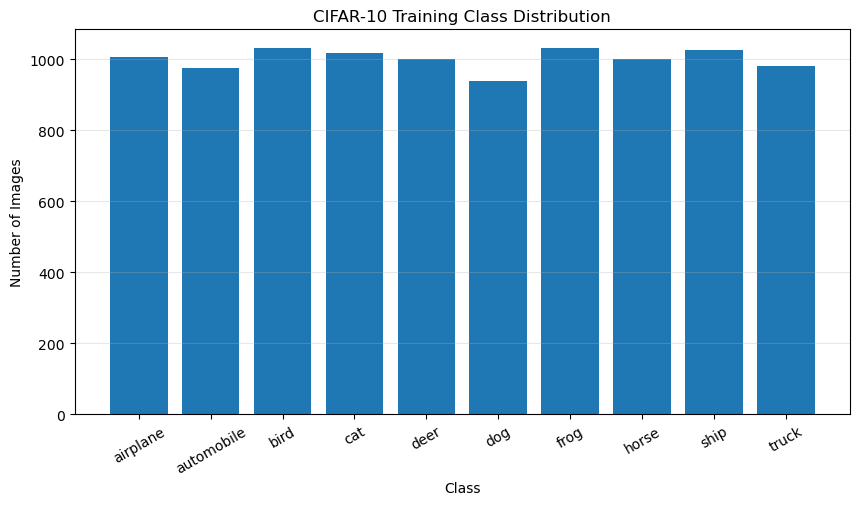

In [4]:
# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Class distribution
counts = np.bincount(y_train, minlength=NUM_CLASSES)

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)
plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

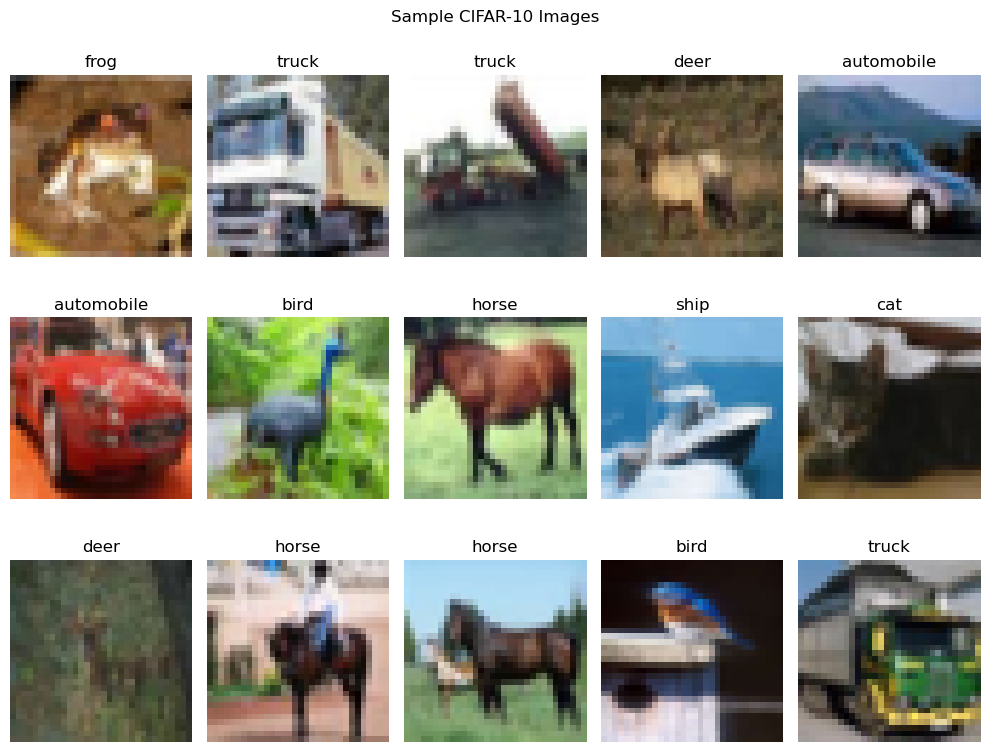

In [5]:
# Visualize sample images
plt.figure(figsize=(10, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

In [6]:
# Resize images for the CNN architectures
x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_test = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE))

x_train = tf.cast(x_train, tf.float32)
x_test = tf.cast(x_test, tf.float32)

# One-hot encode labels
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print("Resized training shape:", x_train.shape)
print("Resized test shape:", x_test.shape)

Resized training shape: (10000, 96, 96, 3)
Resized test shape: (2000, 96, 96, 3)


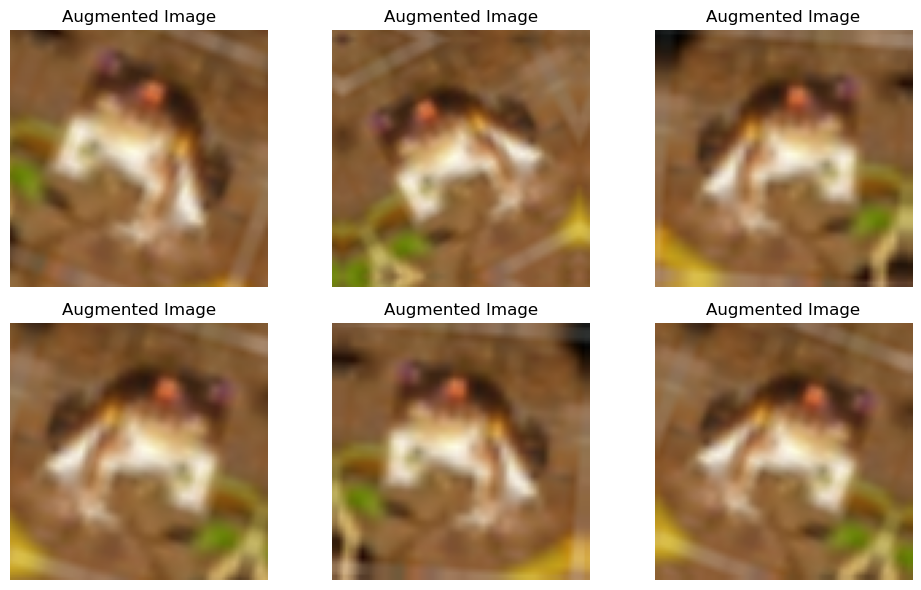

In [7]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10)
], name="data_augmentation")

# Visualize augmentation
sample = tf.expand_dims(x_train[0], 0)

plt.figure(figsize=(10, 6))
for i in range(6):
    augmented = data_augmentation(sample, training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(augmented[0], 0, 255), tf.uint8))
    plt.axis("off")
    plt.title("Augmented Image")

plt.tight_layout()
plt.show()

In [8]:
# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [9]:
# Modified AlexNet-style CNN
def create_alexnet():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(192, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(384, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),

        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="AlexNet_Modified")
    return model

In [10]:
# VGG16 transfer-learning model
def create_vgg16():
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="VGG16_Transfer")
    return model

In [11]:
# ResNet50 transfer-learning model
def create_resnet50():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="ResNet50_Transfer")
    return model

In [12]:
# EfficientNetB0 transfer-learning model
def create_efficientnet():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="EfficientNetB0_Transfer")
    return model

In [13]:
# Compile helper
def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [14]:
# Create and compile all models
models_dict = {
    "AlexNet": compile_model(create_alexnet()),
    "VGG16": compile_model(create_vgg16()),
    "ResNet50": compile_model(create_resnet50()),
    "EfficientNetB0": compile_model(create_efficientnet())
}

for name, model in models_dict.items():
    print(name, "->", model.count_params(), "parameters")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 81s 1us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 64s 1us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
AlexNet -> 2323530 parameters
VGG16 -> 14782154 parameters
ResNet50 -> 23851786 parameters
EfficientNetB0 -> 4215341 parameters


In [15]:
# Display model summaries
for name, model in models_dict.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    model.summary()


AlexNet


Model: "AlexNet_Modified"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 192)    │       110,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 384)    │       663,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,323,530 (8.86 MB)

 Trainable params: 2,321,738 (8.86 MB)

...

Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,341 (16.08 MB)

 Trainable params: 165,514 (646.54 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

In [16]:
# Train and evaluate each model
histories = {}
results = []

for name, model in models_dict.items():
    print("\n" + "=" * 60)
    print("Training:", name)
    print("=" * 60)

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    histories[name] = history

    results.append([
        name,
        test_accuracy * 100,
        test_loss,
        training_time,
        model.count_params()
    ])

    print(f"{name} accuracy: {test_accuracy * 100:.2f}%")
    print(f"{name} loss: {test_loss:.4f}")
    print(f"{name} training time: {training_time:.2f} seconds")


Training: AlexNet
Epoch 1/5


c:\Users\Shruti\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 2276s 7s/step - accuracy: 0.2517 - loss: 2.0301 - val_accuracy: 0.1175 - val_loss: 4.7026
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1484s 5s/step - accuracy: 0.3282 - loss: 1.8023 - val_accuracy: 0.3225 - val_loss: 1.8410
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1465s 5s/step - accuracy: 0.3652 - loss: 1.6986 - val_accuracy: 0.2310 - val_loss: 2.5269
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1452s 5s/step - accuracy: 0.4015 - loss: 1.6226 - val_accuracy: 0.2685 - val_loss: 2.0578
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2375s 8s/step - accuracy: 0.4243 - loss: 1.5506 - val_accuracy: 0.4435 - val_loss: 1.4936
AlexNet accuracy: 44.35%
AlexNet loss: 1.4936
AlexNet training time: 9052.18 seconds

Training: VGG16
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1272s 4s/step - accuracy: 0.4311 - loss: 1.6496 - val_accuracy: 0.5625 - val_loss: 1.3491
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 972s 3s/step - accuracy: 0.5276 - loss: 1.3528 - val_accuracy: 0.5865 - val_loss: 1.1647
Epoch 

In [17]:
# Comparison table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Test Accuracy (%)",
        "Test Loss",
        "Training Time (seconds)",
        "Parameters"
    ]
)

results_df = results_df.sort_values(
    "Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Test Accuracy (%),Test Loss,Training Time (seconds),Parameters
0,VGG16,60.699999,1.081467,4312.058285,14782154
1,AlexNet,44.350001,1.493619,9052.184588,2323530
2,ResNet50,15.250000,3.562546,1453.256225,23851786
3,EfficientNetB0,9.850000,2.314284,547.162995,4215341


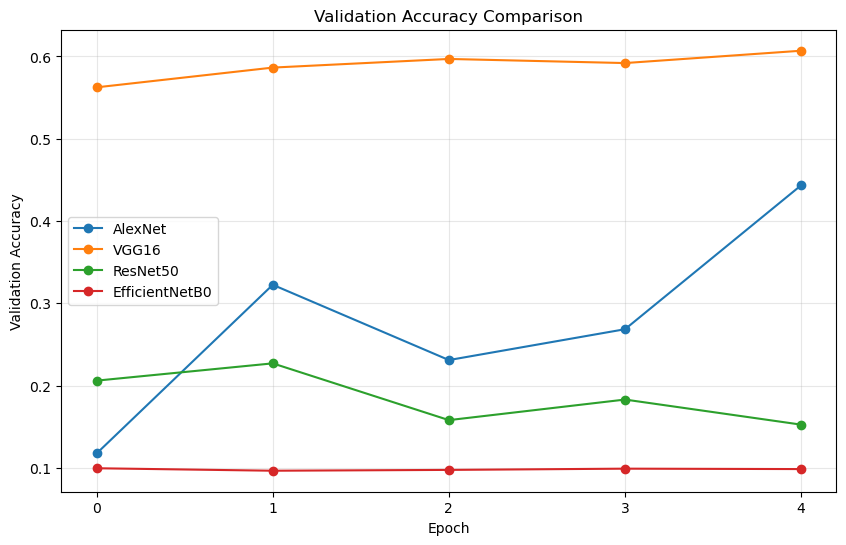

In [18]:
# Compare validation accuracy
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=name
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.xticks(range(EPOCHS))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

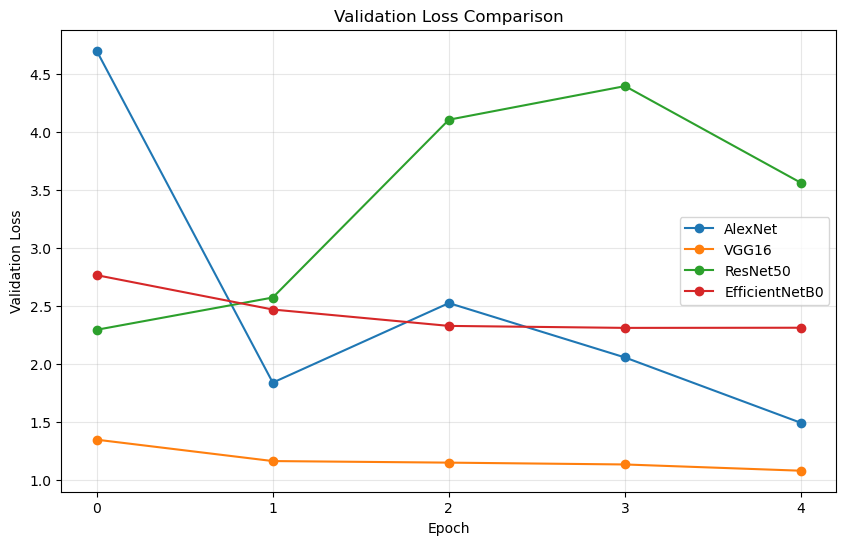

In [19]:
# Compare validation loss
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_loss"],
        marker="o",
        label=name
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(range(EPOCHS))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

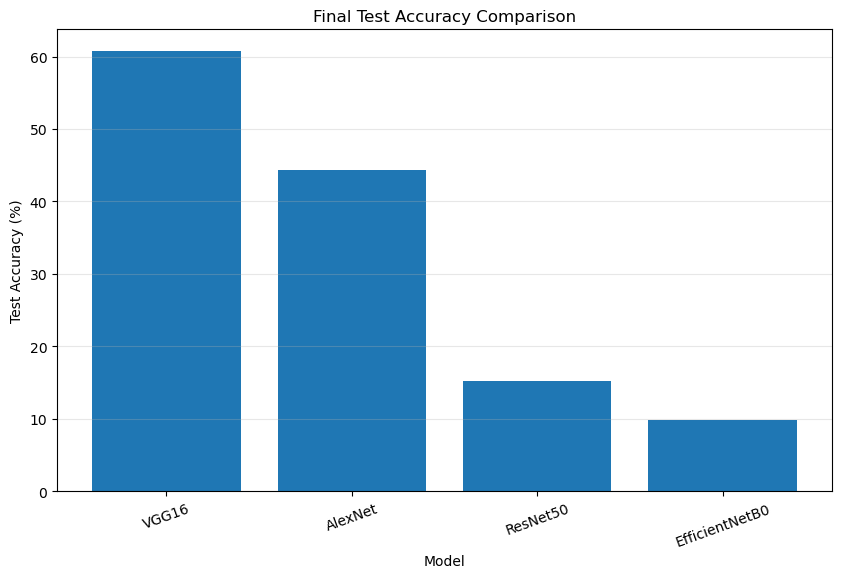

In [20]:
# Compare final accuracy
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Test Accuracy (%)"])
plt.title("Final Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

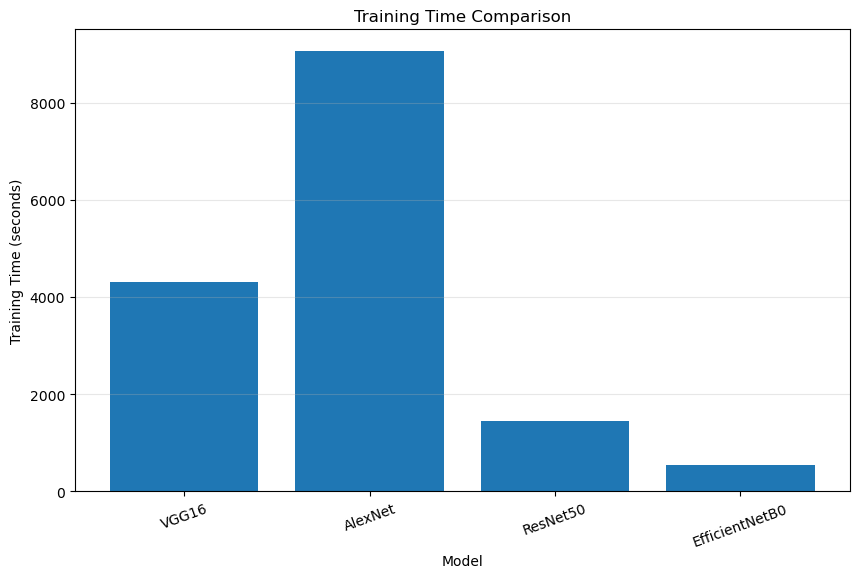

In [21]:
# Compare training time
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Training Time (seconds)"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

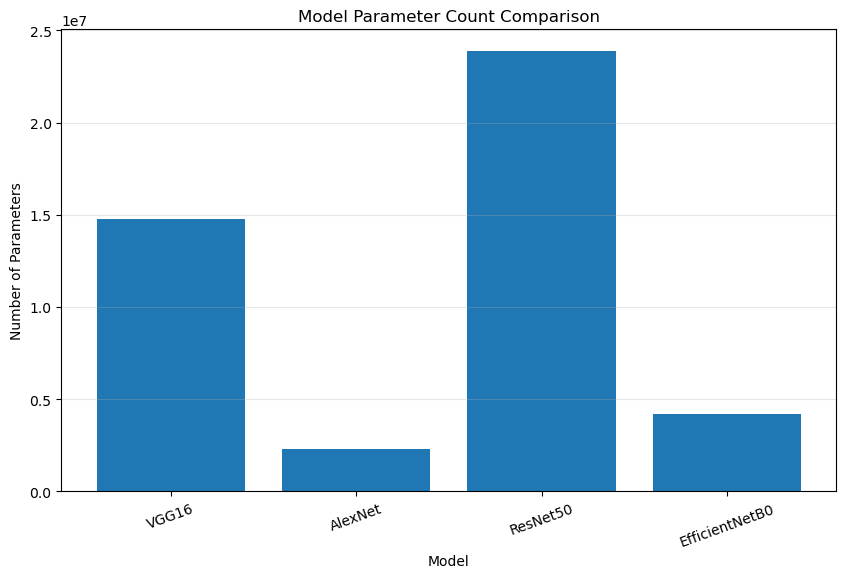

In [22]:
# Compare model parameter counts
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Parameters"])
plt.title("Model Parameter Count Comparison")
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [23]:
# Identify the model with the highest test accuracy
best_row = results_df.iloc[0]

print("=" * 50)
print("HIGHEST TEST ACCURACY")
print("=" * 50)
print("Model:", best_row["Model"])
print(f"Accuracy: {best_row['Test Accuracy (%)']:.2f}%")
print(f"Test Loss: {best_row['Test Loss']:.4f}")
print(f"Training Time: {best_row['Training Time (seconds)']:.2f} seconds")

HIGHEST TEST ACCURACY
Model: VGG16
Accuracy: 60.70%
Test Loss: 1.0815
Training Time: 4312.06 seconds


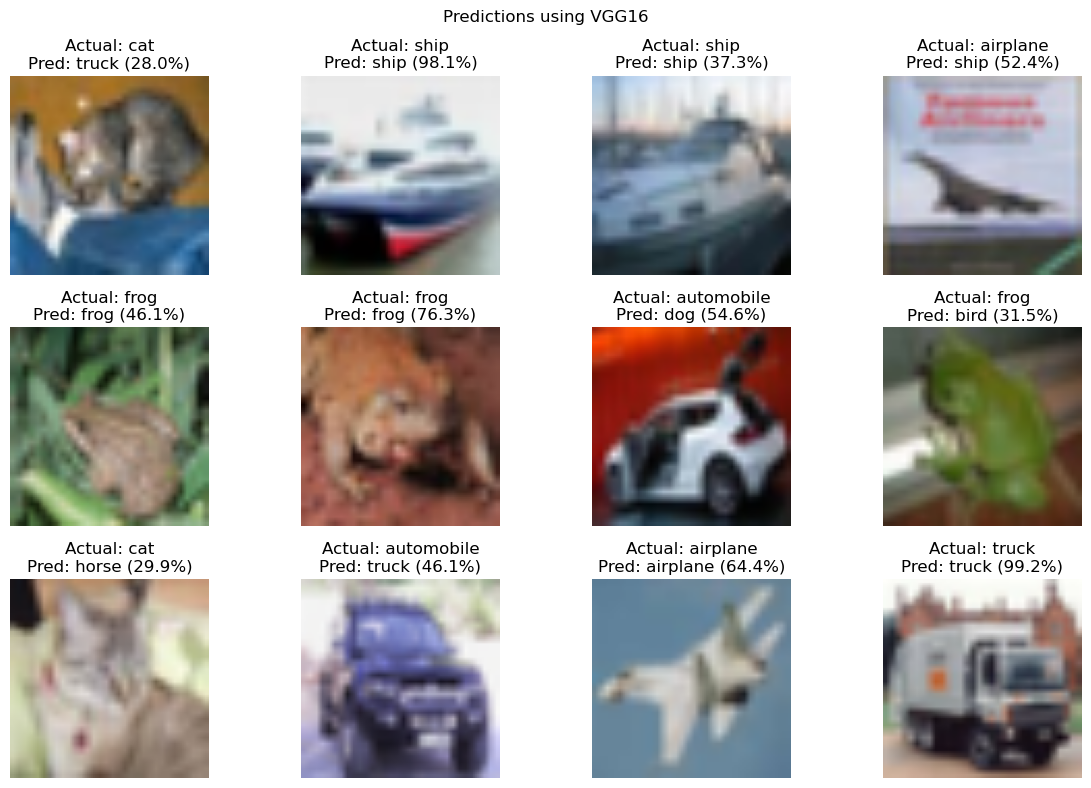

In [24]:
# Visualize predictions from the highest-accuracy model
best_name = best_row["Model"]
best_model = models_dict[best_name]

sample_images = x_test[:12]
sample_labels = y_test[:12]

predictions = best_model.predict(sample_images / 1.0, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(sample_images[i], 0, 255), tf.uint8))
    actual = class_names[sample_labels[i]]
    predicted = class_names[predicted_labels[i]]
    confidence = predictions[i][predicted_labels[i]] * 100
    plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.1f}%)")
    plt.axis("off")

plt.suptitle(f"Predictions using {best_name}")
plt.tight_layout()
plt.show()

Incorrect predictions in displayed sample: 6


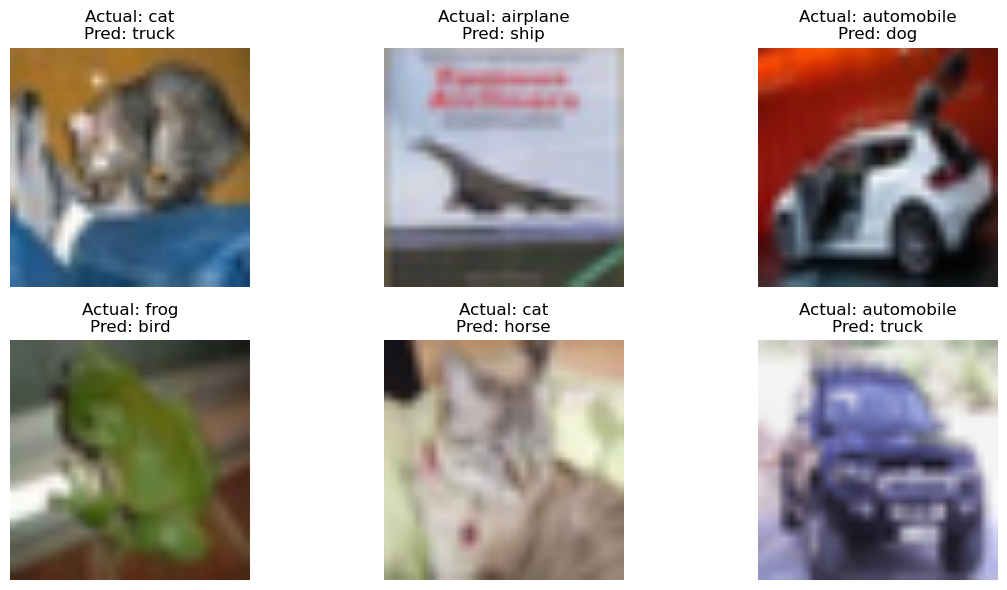

In [25]:
# Find and visualize incorrect predictions
incorrect = np.where(predicted_labels != sample_labels)[0]

print("Incorrect predictions in displayed sample:", len(incorrect))

if len(incorrect) > 0:
    plt.figure(figsize=(12, 6))
    n = min(len(incorrect), 6)

    for j in range(n):
        i = incorrect[j]
        plt.subplot(2, 3, j + 1)
        plt.imshow(tf.cast(tf.clip_by_value(sample_images[i], 0, 255), tf.uint8))
        plt.title(
            f"Actual: {class_names[sample_labels[i]]}\n"
            f"Pred: {class_names[predicted_labels[i]]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [26]:
# Save the comparison results
results_df.to_csv("cnn_architecture_comparison_results.csv", index=False)

print("Comparison results saved as cnn_architecture_comparison_results.csv")

Comparison results saved as cnn_architecture_comparison_results.csv
